# Feature Selection using MRMR

In [1]:
import core.constants as c
from core.utils import save_df_as_table_image, extract_subject_id
import os

import warnings

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from feature_engine.selection import SmartCorrelatedSelection
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedGroupKFold

from feature_engine.selection import MRMR

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
data = pd.read_csv(c.RICKD_FEATURE_SELECTION_PART_2_DATA_FILE_2, index_col=0)
display(data.head())

data.info(verbose=True)

,age,height,weight,gender,is_injured,dom_leg_ankle_df_peak_angle,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_excursion,dom_leg_diff_ankle_eve_excursion,dom_leg_ankle_eve_peak_angle,...,dom_leg_stride_length,dom_leg_diff_stride_length,dom_leg_stride_rate,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_diff_supination_timing,dom_leg_swing_time,dom_leg_diff_swing_time,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,47.0,172.0,61.9,female,True,24.591474,1.552075,-6.336418,1.187877,-1.522192,...,1.891817,0.000000,78.947368,0.000000,61,-3,0.435,0.0150,96.433793,3.847659
100002_20110601T140505,37.0,173.4,70.6,male,True,24.830009,-1.873425,-4.949355,3.761674,-10.091984,...,2.001175,0.000000,81.632653,0.000000,52,23,0.445,0.0250,86.521432,-8.424086
100003_20110601T095930,51.0,186.0,86.5,male,True,25.603645,1.020660,-9.918405,2.724571,-9.056648,...,2.241927,0.000000,78.947368,0.000000,46,-14,0.445,-0.0025,76.611379,-6.069608
100004_20110203T120721,35.0,175.6,59.0,male,True,24.519444,-1.488008,-9.005590,-1.513753,-3.335102,...,1.962250,0.000000,82.191781,0.000000,44,-8,0.440,-0.0200,92.593339,9.320156
100004_20140929T102035,39.0,175.0,61.0,male,False,24.876986,-1.453904,-12.937424,-4.962587,-11.353953,...,2.108590,-0.014643,83.333333,0.574713,43,-4,0.420,-0.0100,87.481400,12.389611


<class 'pandas.core.frame.DataFrame'>
Index: 1813 entries, 100001_20110531T161051 to 201225_20140515T133244
Data columns (total 84 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    1812 non-null   float64
 1   height                                 1805 non-null   float64
 2   weight                                 1808 non-null   float64
 3   gender                                 1812 non-null   object 
 4   is_injured                             1813 non-null   bool   
 5   dom_leg_ankle_df_peak_angle            1813 non-null   float64
 6   dom_leg_diff_ankle_df_peak_angle       1813 non-null   float64
 7   dom_leg_ankle_eve_excursion            1813 non-null   float64
 8   dom_leg_diff_ankle_eve_excursion       1813 non-null   float64
 9   dom_leg_ankle_eve_peak_angle           1813 non-null   float64
 10  dom_leg_diff_ankle_eve_peak_angle     

In [3]:
from core.processing import preprocess_features
from core.model_selection import split_train_test_set
from core.utils import extract_subject_id

y_label = "is_injured"
y = data[y_label]
X = data.drop(columns=[y_label])

X_train, X_test, y_train, y_test = split_train_test_set(
    X, y, test_size=0.2, random_state=RANDOM_STATE, groups=extract_subject_id(X.index.to_series())
)

a = extract_subject_id(X_train.index.to_series())
b = extract_subject_id(X_test.index.to_series())

if np.intersect1d(a, b).size > 0:
    raise ValueError("Error: Some subjects are in both train and test sets")

print(f"Train vs Test split: {X_train.shape[0] / X.shape[0] * 100:.2f}% / {X_test.shape[0] / X.shape[0] * 100:.2f}%")
print(f"Train Shape: {X_train.shape} / Test Shape: {X_test.shape}")
print(f"Injured class distribution Train: {y_train.value_counts().iloc[0] / y_train.shape[0] * 100:.2f}%")
print(f"Injured class distribution Test: {y_test.value_counts().iloc[0] / y_test.shape[0] * 100:.2f}%")

Train vs Test split: 79.76% / 20.24%
Train Shape: (1446, 83) / Test Shape: (367, 83)
Injured class distribution Train: 64.11%
Injured class distribution Test: 61.04%


In [4]:
# Save
X_train.to_csv(c.RICKD_MODEL_1_X_TRAIN_FILE_2)
y_train.to_csv(c.RICKD_MODEL_1_Y_TRAIN_FILE_2)
X_test.to_csv(c.RICKD_MODEL_1_X_TEST_FILE_2)
y_test.to_csv(c.RICKD_MODEL_1_Y_TEST_FILE_2)

In [5]:
# Read
X_train = pd.read_csv(c.RICKD_MODEL_1_X_TRAIN_FILE_2, index_col=0)
y_train = pd.read_csv(c.RICKD_MODEL_1_Y_TRAIN_FILE_2, index_col=0)

X_test = pd.read_csv(c.RICKD_MODEL_1_X_TEST_FILE_2, index_col=0)
y_test = pd.read_csv(c.RICKD_MODEL_1_Y_TEST_FILE_2, index_col=0)

In [6]:
X_test.shape

(367, 83)

In [7]:
feature_categorical_columns = ["gender"]

X_train_prep = preprocess_features(X_train, y_train, feature_categorical_columns=feature_categorical_columns, cat_drop=None)
display(X_train_prep)

X_test_prep = preprocess_features(X_test, y_test, feature_categorical_columns=feature_categorical_columns, cat_drop=None)
display(X_test_prep)

,age,height,weight,dom_leg_ankle_df_peak_angle,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_excursion,dom_leg_diff_ankle_eve_excursion,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,...,dom_leg_stride_rate,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_diff_supination_timing,dom_leg_swing_time,dom_leg_diff_swing_time,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation,gender_female,gender_male
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,0.716796,-0.040618,-0.634605,1.018751,0.682578,1.087067,0.395798,1.485201,0.489915,1.350380,...,-0.851780,-0.050677,0.567631,-0.321703,0.185710,1.168531,0.534832,0.340909,1.0,0.0
100002_20110601T140505,-0.099721,0.113783,0.029859,1.087823,-0.797742,1.421178,1.284185,-0.951915,-0.165420,0.786429,...,-0.321937,-0.050677,-0.343351,2.454867,0.439287,1.922466,-0.059706,-1.060430,0.0,1.0
100003_20110601T095930,1.043402,1.503392,1.244226,1.311845,0.452929,0.224250,0.926212,-0.657482,-0.043043,-0.070744,...,-0.851780,-0.050677,-0.950672,-1.496405,0.439287,-0.150857,-0.654105,-0.791567,0.0,1.0
100004_20110203T120721,-0.263025,0.356413,-0.856093,0.997893,-0.631185,0.444125,-0.536713,0.969637,0.189217,-0.223080,...,-0.211613,-0.050677,-1.153113,-0.855658,0.312498,-1.470244,0.304484,0.965826,0.0,1.0
100004_20140929T102035,0.063582,0.290241,-0.703343,1.101426,-0.616447,-0.502962,-1.727133,-1.310800,-0.187125,-0.959901,...,0.013630,2.300819,-1.254333,-0.428494,-0.194654,-0.716308,-0.002127,1.316334,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201099_20150414T092041,1.533313,-0.757480,0.297173,0.140545,0.277176,-0.021278,0.825370,-2.436115,-0.013370,-0.009384,...,-0.851780,-0.050677,-0.039690,0.959791,0.058922,0.226111,-0.782892,-1.519401,1.0,0.0
201100_20150409T155915,1.125054,-0.261191,0.747787,-1.629869,-0.796010,-0.586809,-0.831980,-0.816868,1.564139,-0.083939,...,-1.347875,-0.050677,1.276173,4.056734,0.946439,0.414595,-0.048359,1.266948,0.0,1.0
201101_20150413T143152,-1.406148,-1.143483,-0.359654,-2.016895,-0.906994,-1.863858,-0.558578,-3.401908,-5.018337,-2.219422,...,0.980854,-0.050677,-0.545791,-2.137152,-0.448230,0.226111,-1.209962,-1.094486,0.0,1.0


,age,height,weight,dom_leg_ankle_df_peak_angle,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_excursion,dom_leg_diff_ankle_eve_excursion,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,...,dom_leg_stride_rate,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_diff_supination_timing,dom_leg_swing_time,dom_leg_diff_swing_time,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation,gender_female,gender_male
id,,,,,,,,,,,,,,,,,,,,,
100005_20110208T120837,-0.388523,-1.364557,-0.964282,0.656959,-0.073148,1.289371,0.057471,-0.081784,-0.597875,0.773328,...,1.498866,0.056030,-1.428310,-0.405225,-1.463583,0.303023,-1.026948,-0.301790,0.0,1.0
100009_20110302T140353,-0.474940,-1.333511,-1.590499,-0.191476,-0.760674,0.648067,-1.040428,1.121860,1.164044,0.612129,...,-0.080413,0.056030,0.754161,2.664393,-0.061530,-0.185691,-0.775161,-0.468158,1.0,0.0
100015_20110329T121446,2.031151,0.839708,1.401424,1.702787,-1.245386,0.693186,0.903633,0.666204,0.757417,0.983494,...,-1.478310,-1.769247,0.555754,-1.252017,0.448307,1.443356,-0.024379,1.498939,0.0,1.0
100024_20110419T164319,1.339816,0.042861,0.288151,0.156784,-0.616852,-0.623237,1.861491,0.482792,0.014893,-0.697395,...,-0.133447,0.056030,0.654957,-0.193528,-0.698827,0.140119,-0.710511,1.180517,1.0,0.0
100030_20110505T115803,0.994148,0.839708,1.109190,1.340105,0.295981,1.412363,0.944314,-0.417449,0.386252,1.738069,...,-0.836846,0.056030,0.952567,0.653264,-0.061530,0.303023,-1.395039,0.677073,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201090_20150402T171016,0.734897,-1.964779,-1.312180,-2.419092,0.110713,-0.249776,-0.259468,-0.587951,-0.739893,-0.144531,...,2.240051,0.056030,-0.535481,0.547415,-1.718502,-1.651832,-1.523579,-1.442591,1.0,0.0
201090_20150402T171510,0.734897,-1.964779,-1.312180,-2.618077,-0.381660,0.069430,0.188507,-0.297157,-0.342716,0.095157,...,3.361403,-3.265324,-0.833091,0.864961,-2.483258,0.303023,-2.134546,-1.868722,1.0,0.0
201092_20141208T180913,0.734897,0.725873,0.148991,0.274217,-0.258905,0.829919,0.850700,0.182958,-0.919680,1.337572,...,-1.300871,0.056030,0.357348,-0.087679,2.487657,-0.022786,2.712623,0.511025,0.0,1.0


In [8]:
# Save
X_train_prep.to_csv(c.RICKD_MODEL_1_X_TRAIN_PREPROCESSED_FILE_2)
X_test_prep.to_csv(c.RICKD_MODEL_1_X_TEST_PREPROCESSED_FILE_2)

In [9]:
# Read
X_train_prep_df = pd.read_csv(c.RICKD_MODEL_1_X_TRAIN_PREPROCESSED_FILE_2, index_col=0)
X_test_prep_df = pd.read_csv(c.RICKD_MODEL_1_X_TEST_PREPROCESSED_FILE_2, index_col=0)

In [10]:
y_train.shape

(1446, 1)

In [11]:
# We want stable importance ranking:
# We want enough complexity to capture non-linear relationships.
# We want enough randomness so feature importances aren’t biased toward high-cardinality variables.
# We want parameters that avoid overfitting
param_grid = {
    "n_estimators": [500],  # More provides more stability.
    "max_depth": [5, 10], 
    "min_samples_leaf": [2, 5, 8],
    "max_features": ["sqrt", "log2"],  # Give smaller features a chance to be selected
    "min_samples_split": [4, 10, 16],  # Proportional to min_samples_leaf
    "bootstrap": [True]  # So each tree sees a slightly different dataset
}

sel = MRMR( 
        method="RFCQ",
        scoring="roc_auc",
        param_grid = param_grid,
        cv=3,
        regression=False,
        max_features=40,
        random_state=RANDOM_STATE,
    )
sel.fit(X_train_prep_df, y_train)

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Docume

MRMR(max_features=40, method='RFCQ',
     param_grid={'bootstrap': [True], 'max_depth': [5, 10],
                 'max_features': ['sqrt', 'log2'],
                 'min_samples_leaf': [2, 5, 8],
                 'min_samples_split': [4, 10, 16], 'n_estimators': [500]},
     random_state=42)

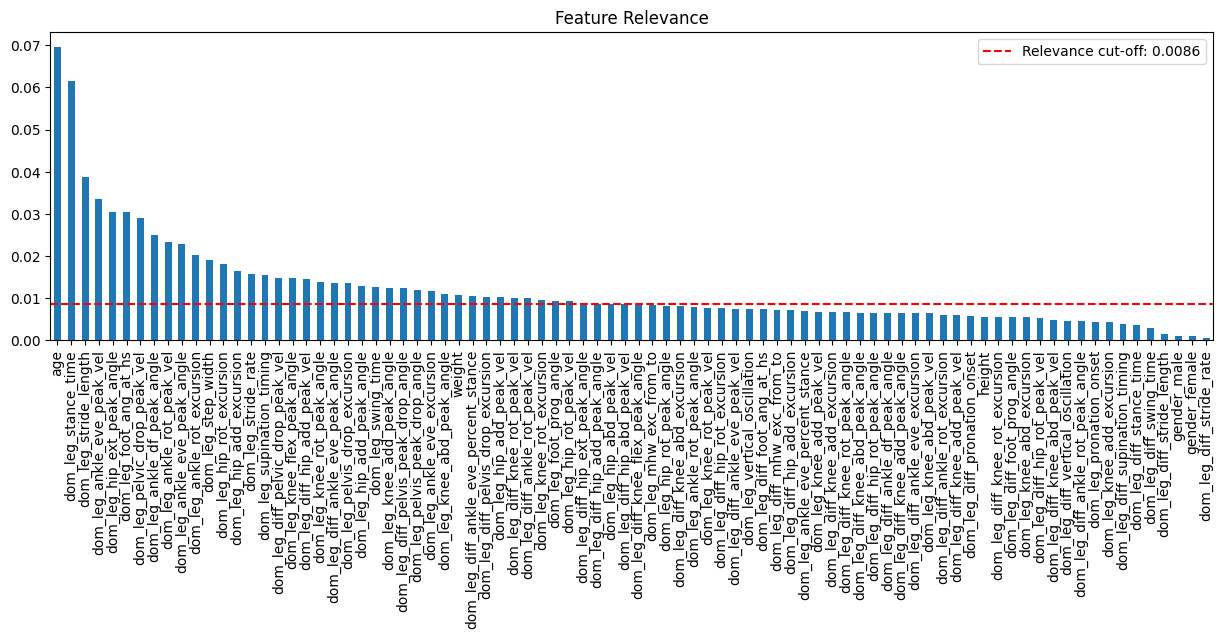

In [17]:
relevance_cutoff = sorted(sel.relevance_, reverse=True)[39]
ax = pd.Series(sel.relevance_, index=sel.variables_).sort_values(
    ascending=False).plot.bar(figsize=(15, 4))
plt.axhline(relevance_cutoff, color='red', linestyle='--', label=f'Relevance cut-off: {relevance_cutoff:.4f}')
plt.title("Feature Relevance")
plt.legend()
plt.show()

In [14]:
sorted_vars = sorted(zip(sel.variables_, sel.relevance_), key=lambda x: x[1], reverse=True)
for i, (var, rel) in enumerate(sorted_vars):
    print(f"{i}: {var}: {rel}")

0: age: 0.06971417055484248
1: dom_leg_stance_time: 0.06156516684738698
2: dom_leg_stride_length: 0.03879836056551662
3: dom_leg_ankle_eve_peak_vel: 0.033381157963989196
4: dom_leg_hip_ext_peak_angle: 0.030461497151414697
5: dom_leg_foot_ang_at_hs: 0.03033123909054132
6: dom_leg_pelvic_drop_peak_vel: 0.029074688035592926
7: dom_leg_ankle_df_peak_angle: 0.024904352219994385
8: dom_leg_ankle_rot_peak_vel: 0.023353444208483027
9: dom_leg_ankle_eve_peak_angle: 0.022876449159026344
10: dom_leg_ankle_rot_excursion: 0.020219706083221656
11: dom_leg_step_width: 0.01902201952466689
12: dom_leg_hip_rot_excursion: 0.018120979365209403
13: dom_leg_hip_add_excursion: 0.016349812391298728
14: dom_leg_stride_rate: 0.01570216264197829
15: dom_leg_supination_timing: 0.015448355478653827
16: dom_leg_diff_pelvic_drop_peak_vel: 0.01481353541752646
17: dom_leg_knee_flex_peak_angle: 0.014668421926157525
18: dom_leg_diff_hip_add_peak_vel: 0.014475504133959495
19: dom_leg_knee_rot_peak_angle: 0.01380435708118

In [15]:
print("="*30)
print("X Train with 40 selected features")
print("="*30)
X_train_sel = sel.transform(X_train_prep_df)
display(X_train_sel.head())
print(X_train_sel.info(verbose=True))

print("\n="*30)
print("X Test with 40 selected features")
print("="*30)
X_test_sel = sel.transform(X_test_prep_df)
display(X_test_sel.head())
print(X_test_sel.info(verbose=True))

X_train_sel.to_csv(c.RICKD_MODEL_1_X_TRAIN_FILE_40_FEATURES_2)
X_test_sel.to_csv(c.RICKD_MODEL_1_X_TEST_FILE_40_FEATURES_2)

X Train with 40 selected features


,age,weight,dom_leg_ankle_df_peak_angle,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_percent_stance,dom_leg_ankle_rot_excursion,dom_leg_ankle_rot_peak_vel,dom_leg_diff_ankle_rot_peak_vel,...,dom_leg_diff_pelvic_drop_peak_vel,dom_leg_pelvis_drop_excursion,dom_leg_pelvis_peak_drop_angle,dom_leg_diff_pelvis_peak_drop_angle,dom_leg_stance_time,dom_leg_step_width,dom_leg_stride_length,dom_leg_stride_rate,dom_leg_supination_timing,dom_leg_swing_time
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,0.716796,-0.634605,1.018751,1.485201,0.489915,1.350380,-0.210953,-0.787213,0.487663,0.930900,...,-0.987459,1.960504,1.668759,1.867601,0.740463,2.003936,-0.288262,-0.851780,0.567631,0.185710
100002_20110601T140505,-0.099721,0.029859,1.087823,-0.951915,-0.165420,0.786429,0.575808,1.309684,1.406198,0.365431,...,0.257177,1.563453,1.451348,1.597808,-0.171642,-0.796692,0.063442,-0.321937,-0.343351,0.439287
100003_20110601T095930,1.043402,1.244226,1.311845,-0.657482,-0.043043,-0.070744,-1.896870,-0.112823,0.676814,-1.045915,...,-0.463421,-0.309219,-0.415110,-0.051693,0.588446,1.194771,0.837726,-0.851780,-0.950672,0.439287
100004_20110203T120721,-0.263025,-0.856093,0.997893,0.969637,0.189217,-0.223080,-0.323348,-0.132529,0.447863,0.114635,...,-0.488005,1.678781,1.612060,1.750754,-0.171642,-1.462716,-0.061744,-0.211613,-1.153113,0.312498
100004_20140929T102035,0.063582,-0.703343,1.101426,-1.310800,-0.187125,-0.959901,0.238624,-0.692795,0.525465,0.437714,...,1.008629,1.409859,1.713655,1.605675,0.132393,-0.917416,0.408901,0.013630,-1.254333,-0.194654


<class 'pandas.core.frame.DataFrame'>
Index: 1446 entries, 100001_20110531T161051 to 201225_20140515T133244
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    1446 non-null   float64
 1   weight                                 1446 non-null   float64
 2   dom_leg_ankle_df_peak_angle            1446 non-null   float64
 3   dom_leg_ankle_eve_peak_angle           1446 non-null   float64
 4   dom_leg_diff_ankle_eve_peak_angle      1446 non-null   float64
 5   dom_leg_ankle_eve_peak_vel             1446 non-null   float64
 6   dom_leg_diff_ankle_eve_percent_stance  1446 non-null   float64
 7   dom_leg_ankle_rot_excursion            1446 non-null   float64
 8   dom_leg_ankle_rot_peak_vel             1446 non-null   float64
 9   dom_leg_diff_ankle_rot_peak_vel        1446 non-null   float64
 10  dom_leg_foot_ang_at_hs                

,age,weight,dom_leg_ankle_df_peak_angle,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_percent_stance,dom_leg_ankle_rot_excursion,dom_leg_ankle_rot_peak_vel,dom_leg_diff_ankle_rot_peak_vel,...,dom_leg_diff_pelvic_drop_peak_vel,dom_leg_pelvis_drop_excursion,dom_leg_pelvis_peak_drop_angle,dom_leg_diff_pelvis_peak_drop_angle,dom_leg_stance_time,dom_leg_step_width,dom_leg_stride_length,dom_leg_stride_rate,dom_leg_supination_timing,dom_leg_swing_time
id,,,,,,,,,,,,,,,,,,,,,
100005_20110208T120837,-0.388523,-0.964282,0.656959,-0.081784,-0.597875,0.773328,-0.735684,-0.052153,0.400662,-0.446960,...,-0.621417,0.042004,0.452286,0.240566,-0.279383,-0.312625,-0.734046,1.498866,-1.428310,-1.463583
100009_20110302T140353,-0.474940,-1.590499,-0.191476,1.121860,1.164044,0.612129,0.441282,-0.892512,-0.883760,-0.705938,...,0.365951,1.789386,2.384075,2.409139,0.174194,0.528068,-0.651982,-0.080413,0.754161,-0.061530
100015_20110329T121446,2.031151,1.401424,1.702787,0.666204,0.757417,0.983494,-0.971077,0.385729,0.975880,0.082863,...,-2.140690,-0.958879,-0.809543,-0.744112,1.686117,1.058469,-0.122057,-1.478310,0.555754,0.448307
100024_20110419T164319,1.339816,0.288151,0.156784,0.482792,0.014893,-0.697395,0.323585,-0.804581,-0.302969,0.928494,...,0.909116,-0.592755,-0.383731,-0.543392,0.778963,0.889744,-1.623041,-0.133447,0.654957,-0.698827
100030_20110505T115803,0.994148,1.109190,1.340105,-0.417449,0.386252,1.738069,-0.029504,0.147290,0.673718,-0.629806,...,0.684804,1.247486,1.095517,1.051803,1.156944,1.708453,-0.876131,-0.836846,0.952567,-0.061530


<class 'pandas.core.frame.DataFrame'>
Index: 367 entries, 100005_20110208T120837 to 201223_20140415T132359
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    367 non-null    float64
 1   weight                                 367 non-null    float64
 2   dom_leg_ankle_df_peak_angle            367 non-null    float64
 3   dom_leg_ankle_eve_peak_angle           367 non-null    float64
 4   dom_leg_diff_ankle_eve_peak_angle      367 non-null    float64
 5   dom_leg_ankle_eve_peak_vel             367 non-null    float64
 6   dom_leg_diff_ankle_eve_percent_stance  367 non-null    float64
 7   dom_leg_ankle_rot_excursion            367 non-null    float64
 8   dom_leg_ankle_rot_peak_vel             367 non-null    float64
 9   dom_leg_diff_ankle_rot_peak_vel        367 non-null    float64
 10  dom_leg_foot_ang_at_hs                 